# 🏆 Tournament Simulator — Monte Carlo
**World Cup 2026 Predictor** · We simulate the ENTIRE tournament 10,000 times with the Poisson
goal model as engine, and count how often each team reaches every stage — up to lifting the trophy.

## How it works
1. Every match is simulated by sampling goals from each team's Poisson distribution
   (λ from the Elo gap; hosts get the home-advantage model on home soil).
2. Group standings → 12 winners + 12 runners-up + 8 best third-placed teams qualify.
3. The knockout bracket is wired exactly like the real fixture (placeholders `1A`, `2B`,
   `3A/B/C/D/F`, `W73`...). Drawn knockout games are decided by an Elo-weighted coin flip
   (extra time / penalties).
4. Repeat 10,000 times and count: P(reach R32), P(QF), ... P(champion).

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(42)

# Artifacts
fixture = pd.read_csv("../data/raw/fixture_2026/fixture_2026.csv")  # original order = match numbering
elo_ratings = pd.read_csv("../data/processed/elo_ratings_2026.csv")
ELO = elo_ratings.set_index("team")["elo"].to_dict()
with open("../data/processed/poisson_params.json") as f:
    PARAMS = json.load(f)

# Harmonize fixture names (same fixes as the other notebooks)
name_map = {"USA": "United States", "Bosnia & Herzegovina": "Bosnia and Herzegovina"}
fixture["team1"] = fixture["team1"].replace(name_map)
fixture["team2"] = fixture["team2"].replace(name_map)

HOSTS = {"United States", "Mexico", "Canada"}

group_matches = fixture[fixture["group"].notna()].copy()
ko_matches = fixture[fixture["group"].isna()].copy().reset_index(drop=True)
ko_matches["match_no"] = range(73, 73 + len(ko_matches))  # FIFA numbering: KO matches are 73-104

teams_2026 = sorted(set(group_matches["team1"]) | set(group_matches["team2"]))
print(len(group_matches), "group matches |", len(ko_matches), "knockout matches |", len(teams_2026), "teams")

# Sanity: every team must have an Elo rating
missing_elo = [t for t in teams_2026 if t not in ELO]
print("Teams without Elo rating:", missing_elo if missing_elo else "none ✅")

72 group matches | 32 knockout matches | 48 teams
Teams without Elo rating: none ✅


## 1. The match engine

In [2]:
def get_lambdas(team1, team2):
    """Expected goals for both teams. Hosts get home advantage on home soil."""
    e1, e2 = ELO.get(team1, 1500), ELO.get(team2, 1500)
    if team1 in HOSTS and team2 not in HOSTS:
        p = PARAMS["home_advantage"]
        d = (e1 - e2) / 400
        return np.exp(p["home_intercept"] + p["home_coef"] * d), np.exp(p["away_intercept"] + p["away_coef"] * d)
    if team2 in HOSTS and team1 not in HOSTS:
        p = PARAMS["home_advantage"]
        d = (e2 - e1) / 400  # host as 'home'
        lam_host = np.exp(p["home_intercept"] + p["home_coef"] * d)
        lam_other = np.exp(p["away_intercept"] + p["away_coef"] * d)
        return lam_other, lam_host
    p = PARAMS["neutral"]
    d = (e1 - e2) / 400
    return np.exp(p["home_intercept"] + p["home_coef"] * d), np.exp(p["away_intercept"] + p["away_coef"] * d)


def sim_match(team1, team2):
    """Sample a score from the Poisson model."""
    lam1, lam2 = get_lambdas(team1, team2)
    return rng.poisson(lam1), rng.poisson(lam2)


def ko_winner(team1, team2):
    """Knockout match: if drawn after 90', an Elo-weighted coin decides (ET/pens)."""
    g1, g2 = sim_match(team1, team2)
    if g1 > g2:
        return team1
    if g2 > g1:
        return team2
    e1, e2 = ELO.get(team1, 1500), ELO.get(team2, 1500)
    p1 = 1 / (1 + 10 ** ((e2 - e1) / 400))
    return team1 if rng.random() < p1 else team2

# Quick test
print("Spain vs Cape Verde sampled 5 times:", [sim_match("Spain", "Cape Verde") for _ in range(5)])

Spain vs Cape Verde sampled 5 times: [(8, 0), (7, 1), (7, 0), (6, 0), (6, 1)]


## 2. Group stage, standings and best thirds

In [3]:
GROUP_FIXTURES = {
    g: list(zip(df["team1"], df["team2"]))
    for g, df in group_matches.groupby("group")
}

def sim_group(group_name):
    """Simulate one group. Returns standings: list of (team, pts, gd, gf) sorted."""
    stats = {}
    for t1, t2 in GROUP_FIXTURES[group_name]:
        for t in (t1, t2):
            stats.setdefault(t, [0, 0, 0])  # pts, gd, gf
        g1, g2 = sim_match(t1, t2)
        stats[t1][1] += g1 - g2; stats[t1][2] += g1
        stats[t2][1] += g2 - g1; stats[t2][2] += g2
        if g1 > g2:
            stats[t1][0] += 3
        elif g2 > g1:
            stats[t2][0] += 3
        else:
            stats[t1][0] += 1; stats[t2][0] += 1
    # FIFA tiebreakers approximated: points, goal difference, goals for, then lots (random)
    return sorted(stats.items(), key=lambda kv: (kv[1][0], kv[1][1], kv[1][2], rng.random()), reverse=True)


def assign_thirds(slots, qualified_thirds):
    """Match the 8 best thirds to the bracket slots respecting allowed groups (backtracking)."""
    slot_ids = list(slots.keys())

    def backtrack(i, remaining, assignment):
        if i == len(slot_ids):
            return assignment
        sid = slot_ids[i]
        for grp in list(remaining):
            if grp in slots[sid]:
                result = backtrack(i + 1, remaining - {grp}, {**assignment, sid: grp})
                if result:
                    return result
        return None

    result = backtrack(0, set(qualified_thirds.keys()), {})
    if result is None:  # extremely rare: relax constraints
        result = dict(zip(slot_ids, qualified_thirds.keys()))
    return {sid: qualified_thirds[grp] for sid, grp in result.items()}

## 3. Full-tournament simulation

In [4]:
# Third-place slots in the bracket: placeholder -> allowed groups
THIRD_SLOTS = {}
for ph in pd.concat([ko_matches["team1"], ko_matches["team2"]]):
    if ph.startswith("3"):
        THIRD_SLOTS[ph] = set(ph[1:].split("/"))

KO_LIST = list(zip(ko_matches["match_no"], ko_matches["round"], ko_matches["team1"], ko_matches["team2"]))
STAGES = ["R32", "R16", "QF", "SF", "Final", "Champion"]
ROUND_TO_STAGE = {"Round of 32": "R16", "Round of 16": "QF", "Quarter-final": "SF", "Semi-final": "Final"}


def sim_tournament():
    """One full tournament. Returns dict: team -> furthest stage reached."""
    reached = {}
    slots = {}        # placeholder -> team  ('1A', '2B', 'W73', ...)
    thirds_pool = {}  # group letter -> (team, pts, gd, gf)

    # Group stage
    for g in GROUP_FIXTURES:
        standings = sim_group(g)
        letter = g[-1]
        slots[f"1{letter}"] = standings[0][0]
        slots[f"2{letter}"] = standings[1][0]
        t3, s3 = standings[2]
        thirds_pool[letter] = (t3, s3[0], s3[1], s3[2])
        reached[standings[0][0]] = "R32"
        reached[standings[1][0]] = "R32"

    # Best 8 thirds
    ranked = sorted(thirds_pool.items(), key=lambda kv: (kv[1][1], kv[1][2], kv[1][3], rng.random()), reverse=True)
    qualified_thirds = {grp: data[0] for grp, data in ranked[:8]}
    for team in qualified_thirds.values():
        reached[team] = "R32"
    slots.update(assign_thirds(THIRD_SLOTS, qualified_thirds))

    # Knockout rounds
    finalists = []
    for match_no, rnd, ph1, ph2 in KO_LIST:
        if rnd in ("Match for third place",):
            continue
        t1, t2 = slots[ph1], slots[ph2]
        if rnd == "Final":
            winner = ko_winner(t1, t2)
            reached[winner] = "Champion"
            reached[t1 if winner == t2 else t2] = "Final"
            continue
        winner = ko_winner(t1, t2)
        loser = t1 if winner == t2 else t2
        slots[f"W{match_no}"] = winner
        slots[f"L{match_no}"] = loser
        reached[winner] = ROUND_TO_STAGE[rnd]
        if rnd == "Semi-final":
            finalists.append(winner)

    return reached

# Smoke test: one tournament
test = sim_tournament()
champ = [t for t, s in test.items() if s == "Champion"]
print("Sample simulated champion:", champ[0])

Sample simulated champion: Senegal


In [5]:
N_SIMS = 10_000
STAGE_ORDER = {"R32": 0, "R16": 1, "QF": 2, "SF": 3, "Final": 4, "Champion": 5}

counts = {t: np.zeros(6, dtype=int) for t in teams_2026}

for _ in range(N_SIMS):
    reached = sim_tournament()
    for team, stage in reached.items():
        # Reaching a stage implies reaching all previous ones
        counts[team][: STAGE_ORDER[stage] + 1] += 1

odds = pd.DataFrame(
    {t: c / N_SIMS * 100 for t, c in counts.items()},
    index=["R32", "R16", "QF", "SF", "Final", "Champion"],
).T.round(1)
odds = odds.sort_values("Champion", ascending=False)

print(f"World Cup 2026 — odds from {N_SIMS:,} simulated tournaments\n")
print(odds.head(16).to_string())

World Cup 2026 — odds from 10,000 simulated tournaments

                R32   R16    QF    SF  Final  Champion
Spain          99.9  84.2  66.0  55.5   40.4      28.8
Argentina      99.0  77.1  63.5  48.7   32.9      18.8
France         97.3  76.2  50.2  33.8   18.3      10.4
Mexico         97.5  72.1  43.9  25.7   13.3       6.5
England        98.8  70.7  38.4  22.2   11.7       5.1
Germany        98.4  70.8  38.1  21.0    9.0       4.0
Portugal       95.0  64.4  35.1  17.3    8.8       3.7
Brazil         96.3  57.7  35.5  18.5    8.3       3.5
Colombia       92.2  58.7  29.0  13.6    5.9       2.4
Netherlands    94.9  51.5  30.4  13.8    5.6       2.4
Ecuador        96.9  64.5  32.3  15.8    6.2       2.3
Morocco        94.3  52.4  30.0  13.8    5.6       2.0
Canada         96.6  62.4  30.2  12.2    4.7       1.8
United States  84.3  53.7  27.2  11.1    4.7       1.6
Japan          93.0  46.7  26.7  11.2    4.4       1.5
Turkey         78.2  49.4  24.2   8.6    3.4       1.1


In [6]:
# Save artifact for the dashboard
odds.reset_index().rename(columns={"index": "team"}).to_csv(
    "../data/processed/tournament_odds.csv", index=False
)
print("Saved -> tournament_odds.csv")

Saved -> tournament_odds.csv


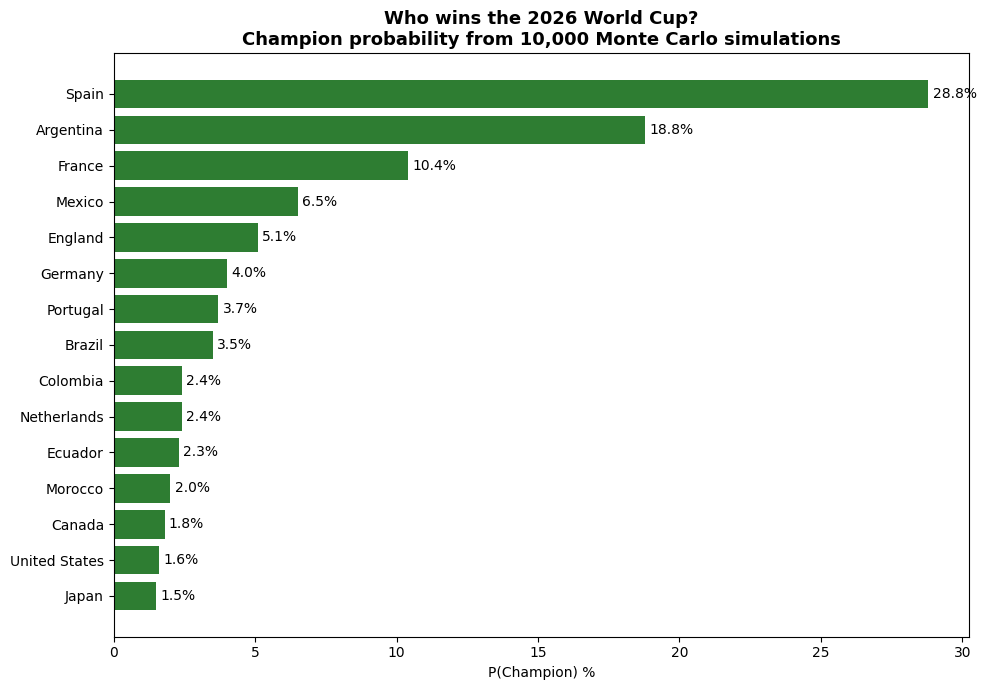

In [7]:
top15 = odds.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top15.index[::-1], top15["Champion"][::-1], color="#2E7D32")
for i, (team, row) in enumerate(top15[::-1].iterrows()):
    plt.text(row["Champion"] + 0.15, i, f"{row['Champion']:.1f}%", va="center", fontsize=10)
plt.title(f"Who wins the 2026 World Cup?\nChampion probability from {N_SIMS:,} Monte Carlo simulations",
          fontsize=13, fontweight="bold")
plt.xlabel("P(Champion) %")
plt.tight_layout()
plt.savefig("../data/processed/champion_odds.png", dpi=200, bbox_inches="tight")
plt.show()

## Conclusions

- The simulator turns a **match-level model into tournament-level insights**: every team's
  probability of reaching each stage, computed from 10,000 simulated World Cups.
- Knockout draws are decided by an Elo-weighted coin flip — a simplification of extra time
  and penalty shootouts.
- The bracket is wired exactly like the real fixture, including the best-third allocation
  constraints (solved per simulation with backtracking).
- These odds will be **re-computed after every matchday** with updated Elo ratings — expect
  big swings when favourites stumble.

**Caveats:** group tiebreakers are approximated (points/GD/GF then lots); host advantage is
applied whenever a host plays a non-host; Elo ratings are frozen at tournament start until
we update them with real results.